# Edge IIoT - Binary Classification (ResNet)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
%load_ext autoreload
%autoreload 2

from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['processed_path']}\n")

#filename = "DNN-EdgeIIoT-dataset"
filename = "ML-EdgeIIoT-dataset"

csv_path = config['processed_path'] / f"{filename}.pkl"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_pickle(csv_path)

print(f"\nDataset loaded with shape: {df.shape}")


--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot/ML-EdgeIIoT-dataset.pkl

Loading dataset... (This may take a while)

Dataset loaded with shape: (140162, 59)


## 1. Pre-processing

In [3]:
df_naive = df.select_dtypes(include=['number'])

target = 'Attack_label'
X = df_naive.drop(columns=[target])
y = df_naive[target]

Y_str = df['Attack_type'] # Used to stratify later

In [4]:
categorical_cols = X.select_dtypes(include=['str', 'object', 'category']).columns
print(f"Check for categorical columns: {list(categorical_cols)}", "\t(Should only include 'Attack_type')")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Check for categorical columns: [] 	(Should only include 'Attack_type')


In [5]:
print(f"\nFinal feature set shape after encoding: {X.shape}")
print(f"NaN values in target variable: {y.isna().sum()}")
print(f"NaN values in features: {X.isna().sum().sum()}")


Final feature set shape after encoding: (140162, 50)
NaN values in target variable: 0
NaN values in features: 0


In [6]:
X_train, X_test, y_train, y_test, Y_str_train, Y_str_test = train_test_split(
    X, y, Y_str, test_size=0.2, random_state=42, stratify=Y_str
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_results = {}

X_train shape: (112129, 50)
X_test shape: (28033, 50)


## 2. Auxiliar Functions

In [7]:
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC'])

In [8]:
def evaluate_model(y_true, y_pred, y_prob, model_name, attack_types=None, tracking_df=None):
    print(f"--- Eval {model_name} ---\n")

    # --- Overall Metrics ---
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    # --- ROC AUC Score ---
    auc_score = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC Score: {auc_score:.4f}\n")
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.show()
    
    # --- Analytics per Attack Type ---
    if attack_types is not None:
        print(f"\n--- Analytics per Attack Type ({model_name}) ---")
        
        y_true_arr = y_true.values if hasattr(y_true, 'values') else y_true
        attack_arr = attack_types.values if hasattr(attack_types, 'values') else attack_types
        
        results_df = pd.DataFrame({
            'True_Label': y_true_arr,
            'Predicted_Label': y_pred,
            'Attack_Type': attack_arr
        })
        
        metrics_list = []
        for attack, group in results_df.groupby('Attack_Type'):
            total = len(group)
            correct = (group['True_Label'] == group['Predicted_Label']).sum()
            accuracy = correct / total
            metrics_list.append({
                'Attack_Type': attack,
                'Total_Samples': total,
                'Correct_Predictions': correct,
                'Detection_Rate (%)': round(accuracy * 100, 2)
            })
            
        metrics_df = pd.DataFrame(metrics_list).sort_values(by='Detection_Rate (%)', ascending=True)
        display(metrics_df)
    
    # --- Tracking Results ---
    if tracking_df is not None:
        new_row = pd.DataFrame({
            'Model': [model_name],
            'Accuracy': [accuracy_score(y_true, y_pred)],
            'Precision': [precision_score(y_true, y_pred, average='weighted')],
            'Recall': [recall_score(y_true, y_pred, average='weighted')],
            'F1_Score': [f1_score(y_true, y_pred, average='weighted')],
            'AUC': [auc_score]
        })
        
        tracking_df = pd.concat([tracking_df, new_row], ignore_index=True)
        return tracking_df

## 3. Deep Learning Implementation. ResNet

### 3.1. Tabular ResNet Architecture & Data Loaders

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
batch_size = 512
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True, 
    drop_last=True
)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [10]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.2):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.bn2(out)
        
        out += residual  # Skip connection
        out = self.relu(out)
        return out

class ResNetTabular(nn.Module):
    # Reduced num_blocks to 2 by default to prevent overfitting
    def __init__(self, input_dim, hidden_dim=128, num_blocks=2, num_classes=1):
        super(ResNetTabular, self).__init__()
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        self.bn_in = nn.BatchNorm1d(hidden_dim)
        self.relu = nn.ReLU()
        
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim, hidden_dim) for _ in range(num_blocks)])
        
        self.fc_out = nn.Linear(hidden_dim, num_classes)
        # Sigmoid REMOVED to output raw logits for BCEWithLogitsLoss

    def forward(self, x):
        out = self.fc_in(x)
        out = self.bn_in(out)
        out = self.relu(out)
        
        out = self.blocks(out)
        
        out = self.fc_out(out)
        return out

### 3.2. Training the Model

In [11]:
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight_value = num_negatives / num_positives

pos_weight = torch.tensor([pos_weight_value], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Binary Cross Entropy with logits (more stable for training)
#criterion = nn.BCELoss() # Binary Cross Entropy

In [12]:
input_dim = X_train_scaled.shape[1]
model = ResNetTabular(input_dim=input_dim).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("Training Complete!")

Starting Training...
Epoch [1/20], Loss: 0.0560
Epoch [5/20], Loss: 0.0444
Epoch [10/20], Loss: 0.0430
Epoch [15/20], Loss: 0.0332
Epoch [20/20], Loss: 0.0295
Training Complete!


### 3.3. Evaluation

--- Eval Tabular ResNet ---

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.84      4846
           1       0.98      0.94      0.96     23187

    accuracy                           0.94     28033
   macro avg       0.87      0.93      0.90     28033
weighted avg       0.95      0.94      0.94     28033

ROC AUC Score: 0.9814



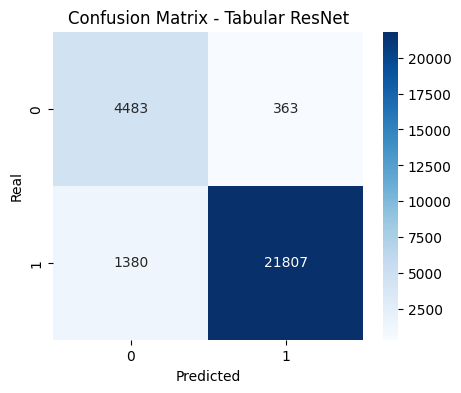


--- Analytics per Attack Type (Tabular ResNet) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
8,Ransomware,2039,1103,54.10
10,Uploading,2052,1640,79.92
4,Fingerprinting,187,161,86.10
5,Normal,4846,4483,92.51
6,Password,1996,1994,99.90
7,Port_Scanning,1938,1937,99.95
3,DDoS_TCP,2050,2049,99.95
0,Backdoor,1998,1997,99.95
12,XSS,1924,1923,99.95
2,DDoS_ICMP,2818,2818,100.00


In [13]:
model.eval()
y_pred_probs = []
y_true_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        y_pred_probs.extend(outputs.cpu().numpy().flatten())
        y_true_list.extend(labels.numpy().flatten())

y_pred_probs = np.array(y_pred_probs)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# Evaluate using your existing helper function
summary_df = evaluate_model(
    y_true=y_test, 
    y_pred=y_pred_classes, 
    y_prob=y_pred_probs, 
    model_name="Tabular ResNet", 
    attack_types=Y_str_test, 
    tracking_df=summary_df
)